CODE ON TRAJECTORIES FOR EX 5 WEEK 1 

In [5]:
# load useful packages

import numpy as np

from matplotlib import pyplot as plt
%matplotlib inline



We will compute a streamline, trajectory and strikeline in 2D. . 

First we define a function for velocity field as a function of x,y,t and plot it to get a first impression. 
Next, we define a grid (x,y points) and make a function which produces the velocity firld on that grid. 

Then we write functions which compute the requires flowlines for any (2D) velocity field. 


In [6]:
def snelheid_locaal (t,x,y):
    # this function takes the position (x,y) and the time t 
    # to give the value of the velocity in x-direction (u) and  y-direction (v)
    
    #you can of course choose another velocity field... 
    
    #EXAMPLE FIELD 
    # some constants
    
    u0 = 1
    v0 = -1
    pi=np.pi 
    
    u = u0 * x * np.cos(t*2*pi)
    v = v0 * y * np.sin(t*2*pi) 

    
    return u,v 


def snelheid_veld (xmin,xmax,nx,ymin,ymax,ny,t):
    # make a grid in x and y
    # and for each gridnpoint, give the velocity (u,v) at time t. 
    
    xlin = np.linspace(xmin, xmax, nx)
    ylin = np.linspace(ymin, ymax, ny)
    xx, yy = np.meshgrid(xlin, ylin)
    
    (uu,vv) = snelheid_locaal(t,xx,yy)
    
    return xx,yy,uu,vv
    
    

Make some plots to get an impression of the field. 

See ch. 10 and 11 of this link for inspiration: https://earth-env-data-science.github.io/intro 

<ipython-input-7-afb5760e7acd>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax0.pcolormesh(xx,yy,vv)                           # plot the component uu in the first subplot


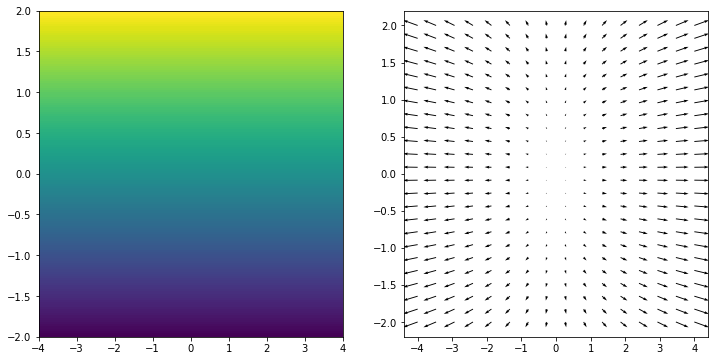

In [7]:
fig = plt.figure(figsize=(12,6))       #define a plot in matplotlib (plt)
axes = fig.subplots(nrows=1, ncols=2)  # axes are subplots
ax0,ax1=axes                           # give names to each subplot

t=0.9          # time where you want to plot

(xx,yy,uu,vv)=snelheid_veld (-4,4,100,-2,2,150,t)  # generate the velocuty field for that time (uu,vv)
ax0.pcolormesh(xx,yy,vv)                           # plot the component uu in the first subplot

(xx,yy,uu,vv)=snelheid_veld (-4,4,16,-2,2,24,t)    # same field met lower resolution 
ax1.quiver(xx,yy, uu, vv)                          # visualise u and v with a quiver plot (arrows)

Compute the trajectory. 

Below you find a piece of code to compute the trajectory, making use of the function snelheid_locaal which gives the velocity at any given position and time. 

Study the function compute_traj carefully and try to understand what it does. 

Then, use the cell below to actually compute trajectories for given initial conditions. 
Also, investigate how the precision changes with the number of timesteps used. 

In [8]:
def compute_traj(x0,y0,tmin,tmax,nt):
    # this function computes the trajectory of a particle for starting point (x0,y0) at time tmin,
    # up to time tmax, and with nt time steps. Velocity field will be generated using the functions from above. 
    
    # define some vectors to store results
    xtraj=np.zeros(nt+1)  #indices of this vector are 0,1,... nt-1,nt
    ytraj=np.zeros(nt+1)
    ttraj=np.zeros(nt+1)
    dt=(tmax-tmin)/nt
    
    # fix the initial conditions 
    xtraj[0]=x0;
    ytraj[0]=y0;
    
    # now loop over all time steps 
    for it in range (0,nt):    #this in fact means: 0,1,2,... nt-1
        (u,v) = snelheid_locaal(ttraj[it],xtraj[it],ytraj[it]) 
    
        ttraj[it+1]=ttraj[it]+dt
        xtraj[it+1]=xtraj[it]+dt*u
        ytraj[it+1]=ytraj[it]+dt*v
        
    return ttraj,xtraj,ytraj


        

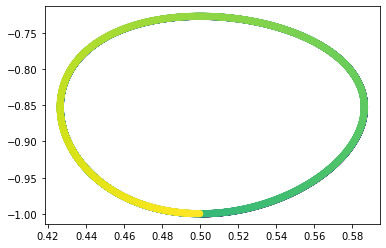

In [9]:
nt=5000  
tmin=0 
tmax=3

x0=0.5
y0=-1


(tt,xx,yy) = compute_traj(x0,y0,tmin,tmax,nt)


plt.scatter(xx,yy,c=tt)